# Dai et al 2024 Replication
handling the catalogue and getting basic catalogue information. we want to divide our exoplanet archive catalogue into three subsets: rv dataset, transit (we include TTVs in this) dataset and then a combination of the two.

the second is what we use for the dai et al 2024 replication 

In [1]:
import os
import sys
currdir = os.getcwd()
datadir = lambda file: f'{currdir}/data/{file}'
import numpy as np
import pandas as pd

sys.path.insert(0, currdir)
import functionalities.general as gen
import functionalities.pairstats as pair

## Exoplanet Archive Catalogue
Our downloaded file from the NASA Exoplanet Archive is from the 10th of July, 2026. Because the column and header information is given initially, we have to skip rows to load it in successfully. Finally, note we set low_memory=False in order to silence the DtypeWarning: Columns (3,4) have mixed types. 
documentation exoarch2026.07.10.csv
```python
pd.read_csv(datadir('exoarch2026.07.10.csv'), skiprows=292, low_memory=False)
```

The function ```catstats``` can either print the catalogue information or simply turn information in a row. We compute this for the overall catalogue, the multi-planet subsample and finally, for our combined transiting and RV sample only. Whereas we identify the discovery system method by pairs below, our criteria for our combined RV and transiting sample is stricter: all systems must only have RV, transits and TTVs as their detection methods to qualify. 

In [2]:
allcat = pd.read_csv(datadir('exoarch2026.07.10.csv'), skiprows=292, low_memory=False)
cat = pair.getDefaultCat(allcat, datadir('usefulcols.txt'), \
                        savefile=datadir('multicat'), treatbinary=True)
cat.reset_index(drop=True, inplace=True)
# catwbinary = pair.getDefaultCat(allcat, datadir('usefulcols.txt'), binary=False)
# mismatchdf = pair.handlebinary(catwbinary, return_mismatch=True)

discmthd = np.append(np.array(['Imaging', 'Microlensing']), gen.DISCM)
allcatrow = pair.catstats(allcat, verbose=False, counthres=discmthd)
multicatrow = pair.catstats(cat, verbose=False, counthres=discmthd)
# Isolate by detection method. 
comhn = cat.hostname[np.isin(cat.discoverymethod, gen.DISCM)]
comdf1 = cat[np.isin(cat.hostname, comhn)]
rmhn = comdf1.hostname[~np.isin(comdf1.discoverymethod, gen.DISCM)]
comcat = comdf1[~np.isin(comdf1.hostname, rmhn)]
# comcat.to_csv(datadir('rv-transit-catalogue.csv'), index=False)
comcatrow = pair.catstats(comcat, verbose=False, counthres=1)
print()
print(f'The mixed systems which include discovery methods of {', '.join(gen.DISCM)} are removed:')
comdf1.loc[np.isin(comdf1.hostname, rmhn), gen.QUICKCOLS]

At a glance: 2645 planets in 1061 systems. BUT: 
1. 18 circumbinary planets orbiting 8 pairs. 
2. 79 hosts with stellar companion(s) (212 planets about such hosts) 
3. 26 planets in systems with >= 2 planet-hosting stars. Of such 14 stars, those hosting one planet are removed: ['HD 133131 B' 'HD 20782' 'HD 41004 A' 'HD 41004 B' 'TOI-2267 B'
 'WASP-94 A' 'WASP-94 B' 'XO-2 N'].

The mixed systems which include discovery methods of Radial Velocity, Transit, Transit Timing Variations are removed:


,pl_name,hostname,discoverymethod,sy_pnum,pl_orbper,pl_rade,pl_radj,pl_ratror,pl_masse,pl_massj,pl_msinie,pl_msinij
2617,bet Pic b,bet Pic,Imaging,3,8682.0,NaN,NaN,NaN,2765.107141,8.7,NaN,NaN
2618,bet Pic c,bet Pic,Radial Velocity,3,1202.0,NaN,NaN,NaN,2765.107141,8.7,NaN,NaN
2619,bet Pic d,bet Pic,Imaging,3,33200.0,14.123316,1.26,NaN,762.788177,2.4,NaN,NaN


## Ordering the Catalogue by Detection Method

Subsequently, we want to inspect the distribution of mean motion resonance pair statistics by both detection method and by size/radius categorisation. Therefore, we sort our overall catalogue by 

 However, there remains overlap with RV and TTVs (as shown), therefore, we filter for transiting systems rather than transiting planets for completion.

In [3]:
infodict = {'pairname': 'pl_name', 'discmthd': 'discoverymethod'}
pairdf = cat.groupby(['hostname'])[cat.columns].apply(lambda sys: pair.sysMMRdf(sys, infodict=infodict))

def sysbydisc(discopts, df, pairdf=None):
    '''
    '''
    if pairdf is None:
        idict = {'pairname': 'pl_name', 'discmthd': 'discoverymethod'}
        sysfunc = lambda sys: pair.sysMMRdf(sys, infodict=idict)
        pairdf = df.groupby(['hostname'])[df.columns].apply(sysfunc)

    hn = pairdf.hostname[np.isin(pairdf.discmthd, discopts)]
    return df[np.isin(df.hostname, hn)]
    
rvcat = sysbydisc(['Radial Velocity-Radial Velocity'], cat, pairdf)
rvcatrow = pair.catstats(rvcat, verbose=False, counthres=1)
# rvcat.to_csv(datadir('rv-catalogue.csv'), index=False)
transoptions = ['Transit Timing Variations-Transit Timing Variations', \
                'Transit Timing Variations-Transit', 'Transit-Transit', \
                'Transit-Transit Timing Variations']
transcat = sysbydisc(transoptions, cat, pairdf)
# transcat.to_csv(datadir('transit(dai2024)catalogue.csv'), index=False)
transcatrow = pair.catstats(transcat, verbose=False, counthres=1)

overlaphn = np.intersect1d(rvcat.hostname, transcat.hostname)
overlapdf = cat[np.isin(cat.hostname, overlaphn)]
if overlapdf.empty: print('No overlap between Dai et al 2024 Catalogue and RV Multi(s)!')
else: _ = pair.catstats(overlapdf, verbose=True, counthres=1)
pd.DataFrame([allcatrow, multicatrow, comcatrow, transcatrow, rvcatrow], \
index=['All', 'Multi-Planet Only', 'Combination Multi(s)', \
       'Dai et al 2024', 'RV Multi(s)']).astype('Int64')

There are 20 planets orbiting 4 stars in 4 systems. Of such: 
	0 2-planet systems and  4 systems with > 2 planets. 
	Discovery methods: Radial Velocity (9); Transit (11). 
	0 circumbinary planets and  1 companioned stars in 1 systems with 4 planets.


,# Planets,# Host Stars,# Systems,# 2-Planet Systems,# > 2-Planet Systems,Imaging,Microlensing,Radial Velocity,Transit,Transit Timing Variations,# Circumbinary Planets,# Companioned Stars,> 1 Star Systems,# Planets in > 1 Star Systems
All,6319,4735,4728,706,348,98,281,1195,4662,40,54,420,413,565
Multi-Planet Only,2637,1053,1049,704,345,18,18,638,1905,39,18,85,81,230
Combination Multi(s),2581,1028,1024,684,340,<NA>,<NA>,637,1905,39,5,79,75,217
Dai et al 2024,1886,736,735,470,265,<NA>,<NA>,25,1822,39,3,41,40,125
RV Multi(s),575,228,224,149,75,<NA>,<NA>,551,24,<NA>,0,34,30,86


## Dai et al. 2024's Delta Calculation
Replicating Dai et al. 2024's Figure 1 and Figure 2. We consider only the systems which include a pair of transiting and/or TTV planets. 

In [4]:
daimmrdf = transcat.groupby(['hostname'])[transcat.columns].apply(pair.sysMMRdf)
mismatchdf = pair.handlebinary(cat, return_mismatch=True)
_, _ = pair.mmrStats(daimmrdf, verbose=True)
daimmrdf = pair.whichdelta(daimmrdf, returndf=True)
daimmrdf[np.isin(daimmrdf, mismatchdf.hostname)]

At a glance: 2637 planets in 1053 systems. BUT: 
1. 18 circumbinary planets orbiting 8 pairs. 
2. 79 hosts with stellar companion(s) (212 planets about such hosts) 
3. 18 planets in systems with >= 2 planet-hosting stars. Of such 6 stars, those hosting one planet are removed: [].
1150 possible pairs catalogued 736 planet-hosting stars within 736 systems. If overlapping, 201 first-order versus 197 first-order; 71 second-order to 71 respectively. Such resonant pairs are hosted by 201 stars within 201 systems. For multi-resonant systems: 42 stars host >= 2 MMR pairs in 42 systems with 143 total pairs. The # stars with >= 2 pairs is 265.
No nan values in the original dataframe!


,,firstMMR,firstdelta,hostname,nanflag,pairname,pnumflag,secondMMR,seconddelta,which
hostname,,,,,,,,,,
TOI-2267 A,0,3:2,0.017884,TOI-2267 A,0,TOI-2267 c-TOI-2267 b,1,5:3,-0.083905,1


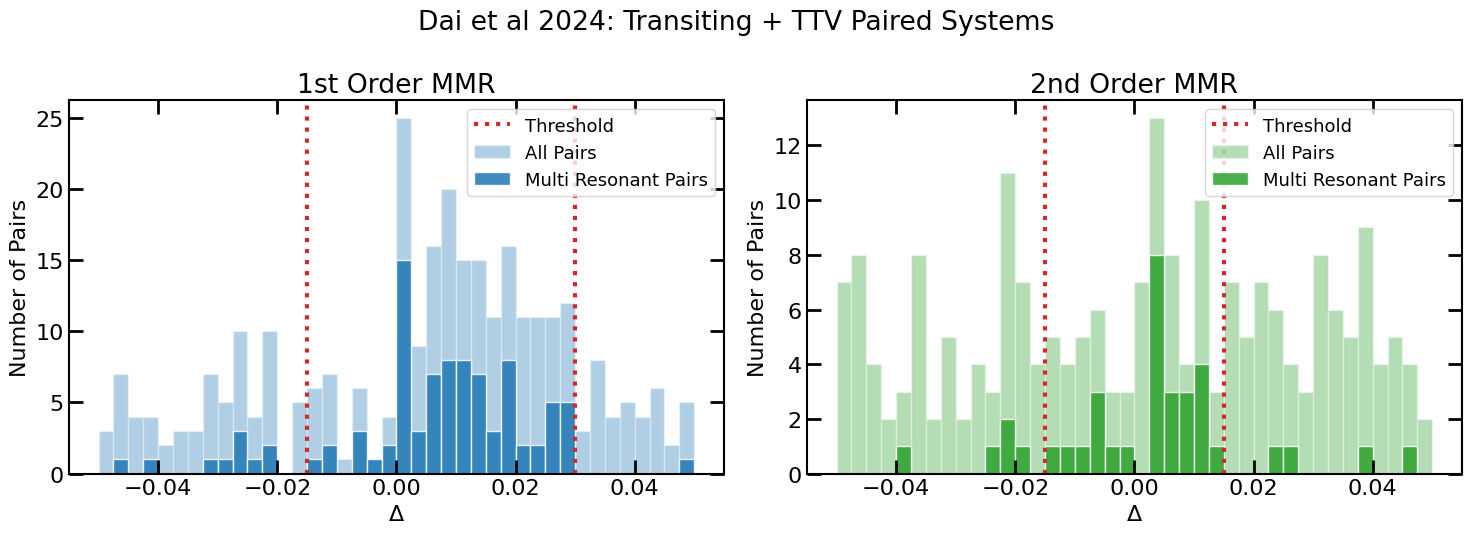

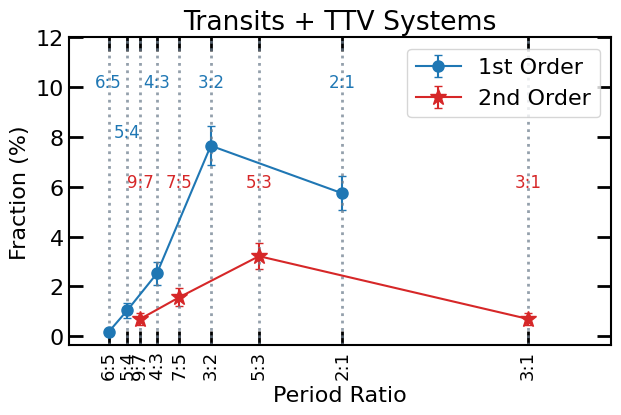

In [5]:
fig, axs = gen.setupPlots((15, 5.5), sharex=True, logscale=0)
axs = pair.mmrHistFig(axs, daimmrdf)
fig.suptitle('Dai et al 2024: Transiting + TTV Paired Systems')
fig.tight_layout()
fig.show()

fig, ax = gen.setupPlot((7, 4), logscale=2)
ax = pair.mmrbarSingleWrapper(daimmrdf, ax)
ax.set_xlim(1.1, ax.get_xlim()[-1])
ax.set_title('Transits + TTV Systems')
fig.show()